# Rail Operations Forecaster
## Notebook 07 — Temporal Modeling with LSTM

**Business Objective:**  
Evaluate whether a temporal sequence model can improve next-day terminal dwell forecasting by learning short-run operating patterns across multiple days. This notebook introduces an LSTM-based approach using rolling terminal-day sequences and compares its performance to the Phase 1 tabular LightGBM models.

> **Audience:** This notebook is written for analysts and technical reviewers who want to understand whether sequence-aware modeling adds predictive value beyond a strong tabular baseline.

## Temporal modeling approach

The Phase 1 LightGBM model treated each terminal-day row as a largely independent observation. That worked well, but it did not explicitly model how operating conditions evolve over several consecutive days.

This notebook tests whether a temporal model can learn short-run buildup patterns such as rising inbound pressure, persistent high yard occupancy, or repeated resource shortfalls that may influence next-day dwell. The first Phase 2 experiment uses an LSTM and a 7-day rolling input window while keeping the same forecasting target and holdout structure used in Phase 1.

In [1]:
from pathlib import Path

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 20)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

np.random.seed(42)
tf.random.set_seed(42)

print("Imports OK")
print("TensorFlow version:", tf.__version__)

I0000 00:00:1776786697.039676    7139 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776786697.043285    7139 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776786697.523547    7139 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776786698.866805    7139 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

Imports OK
TensorFlow version: 2.21.0


## Load and prepare the dataset

The terminal dwell dataset covers 8 terminals from approximately 2022-01-01 through 2024-12-31 and contains 8,760 rows. Terminal identity is encoded using dummy variables, producing 16 model input features in total.

The modeling table is sorted by terminal and date before any sequence construction to ensure that rolling windows are built in strict chronological order within each terminal.

In [2]:
# Load the dataset
project_root = Path.cwd().resolve().parent
data_path = project_root / "data" / "synthetic" / "phase1_terminal_dwell.csv"

df = pd.read_csv(data_path, parse_dates=["date"])

# Sort by terminal and date for proper temporal sequencing
df = df.sort_values(["terminal_id", "date"]).reset_index(drop=True)

# Official Phase 2 operational features
base_feature_cols = [
    "inbound_train_count",
    "inbound_car_count",
    "cars_on_hand",
    "yard_occupancy_pct",
    "crew_starts_available",
    "locomotive_availability_pct",
    "is_weekend",
    "month",
]

target_col = "target_dwell_hours"
split_date = pd.Timestamp("2024-07-01")

# Create terminal dummy variables
terminal_dummies = pd.get_dummies(df["terminal_id"], prefix="terminal")

# Build modeling dataframe
df_model = pd.concat(
    [
        df[["date", "terminal_id", target_col] + base_feature_cols],
        terminal_dummies
    ],
    axis=1
)

# Final feature list
dummy_cols = terminal_dummies.columns.tolist()
model_feature_cols = base_feature_cols + dummy_cols

print("df shape:", df.shape)
print("df_model shape:", df_model.shape)
print("Number of model features:", len(model_feature_cols))
print(model_feature_cols)
display(df_model.head())

df shape: (8760, 13)
df_model shape: (8760, 19)
Number of model features: 16
['inbound_train_count', 'inbound_car_count', 'cars_on_hand', 'yard_occupancy_pct', 'crew_starts_available', 'locomotive_availability_pct', 'is_weekend', 'month', 'terminal_T01', 'terminal_T02', 'terminal_T03', 'terminal_T04', 'terminal_T05', 'terminal_T06', 'terminal_T07', 'terminal_T08']


,date,terminal_id,target_dwell_hours,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,terminal_T01,terminal_T02,terminal_T03,terminal_T04,terminal_T05,terminal_T06,terminal_T07,terminal_T08
0,2022-01-01,T01,19.700,13,304,532,59.100,13,92.300,1,1,True,False,False,False,False,False,False,False
1,2022-01-02,T01,19.500,11,223,461,51.200,11,95.300,1,1,True,False,False,False,False,False,False,False
2,2022-01-03,T01,20.000,10,219,448,49.800,18,85.700,0,1,True,False,False,False,False,False,False,False
3,2022-01-04,T01,20.400,7,138,350,38.900,14,88.500,0,1,True,False,False,False,False,False,False,False
4,2022-01-05,T01,20.700,9,175,361,40.100,17,90.500,0,1,True,False,False,False,False,False,False,False


## Scale the sequence features

To prepare the data for LSTM training, the sequence input features are standardized using `StandardScaler`.

The scaler is fit only on rows from the training period before `2024-07-01` to prevent data leakage. The fitted scaler is then applied to the full modeling table so rolling sequences can be built consistently across the full timeline.

In [3]:
scaler = StandardScaler()

train_rows_for_scaling = df_model["date"] < split_date

df_model_scaled = df_model.copy()

scaler.fit(df_model.loc[train_rows_for_scaling, model_feature_cols])

df_model_scaled[model_feature_cols] = scaler.transform(
    df_model[model_feature_cols]
)

print("Scaling complete.")
print("Scaled feature matrix shape:", df_model_scaled[model_feature_cols].shape)
display(df_model_scaled.head())

Scaling complete.
Scaled feature matrix shape: (8760, 16)


,date,terminal_id,target_dwell_hours,inbound_train_count,inbound_car_count,cars_on_hand,yard_occupancy_pct,crew_starts_available,locomotive_availability_pct,is_weekend,month,terminal_T01,terminal_T02,terminal_T03,terminal_T04,terminal_T05,terminal_T06,terminal_T07,terminal_T08
0,2022-01-01,T01,19.700,0.596,0.625,0.503,0.655,-0.433,1.006,1.575,-1.448,2.646,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378
1,2022-01-02,T01,19.500,0.139,-0.133,0.323,0.432,-0.750,1.728,1.575,-1.448,2.646,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378
2,2022-01-03,T01,20.000,-0.089,-0.170,0.290,0.393,0.360,-0.583,-0.635,-1.448,2.646,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378
3,2022-01-04,T01,20.400,-0.775,-0.928,0.043,0.086,-0.274,0.091,-0.635,-1.448,2.646,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378
4,2022-01-05,T01,20.700,-0.318,-0.582,0.070,0.119,0.201,0.573,-0.635,-1.448,2.646,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378,-0.378


## Build rolling 7-day sequences

The LSTM requires a 3D input structure: samples, time steps, and features.

To create this structure, 7-day rolling windows are built separately within each terminal. Each sequence contains the prior 7 days of scaled operational features, and the prediction target is the next-day `target_dwell_hours` for that terminal.

In [4]:
sequence_length = 7

X_sequences = []
y_values = []
target_dates = []
target_terminals = []

for terminal in df_model_scaled["terminal_id"].unique():
    terminal_data = (
        df_model_scaled[df_model_scaled["terminal_id"] == terminal]
        .sort_values("date")
        .reset_index(drop=True)
    )

    X_terminal = terminal_data[model_feature_cols].to_numpy(dtype=np.float32)
    y_terminal = terminal_data[target_col].to_numpy(dtype=np.float32)
    dates_terminal = terminal_data["date"].to_numpy()

    for i in range(sequence_length, len(terminal_data)):
        X_sequences.append(X_terminal[i-sequence_length:i])
        y_values.append(y_terminal[i])
        target_dates.append(dates_terminal[i])
        target_terminals.append(terminal)

X_sequences = np.array(X_sequences, dtype=np.float32)
y_values = np.array(y_values, dtype=np.float32)
target_dates = np.array(target_dates)
target_terminals = np.array(target_terminals)

print("Sequence building complete.")
print("X_sequences shape:", X_sequences.shape)
print("y_values shape:", y_values.shape)
print("One sequence shape:", X_sequences[0].shape)
print("First target date:", target_dates[0])
print("First target terminal:", target_terminals[0])

Sequence building complete.
X_sequences shape: (8704, 7, 16)
y_values shape: (8704,)
One sequence shape: (7, 16)
First target date: 2022-01-08T00:00:00.000000
First target terminal: T01


## Split sequences into training and test sets

The temporal sequences are split using the same holdout boundary as Phase 1.

Sequences with target dates before `2024-07-01` are assigned to the training set, and sequences with target dates on or after `2024-07-01` are assigned to the test set. The split is based on the target date, not the first date in the rolling window, to preserve a proper forecasting setup.

In [5]:
target_dates = pd.to_datetime(target_dates)

train_seq_mask = target_dates < split_date
test_seq_mask = target_dates >= split_date

X_train = X_sequences[train_seq_mask]
X_test = X_sequences[test_seq_mask]
y_train = y_values[train_seq_mask]
y_test = y_values[test_seq_mask]

train_dates = target_dates[train_seq_mask]
test_dates = target_dates[test_seq_mask]

print("Train/test split complete.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("First training target date:", train_dates.min())
print("Last training target date:", train_dates.max())
print("First test target date:", test_dates.min())
print("Last test target date:", test_dates.max())

Train/test split complete.
X_train shape: (7240, 7, 16)
X_test shape: (1464, 7, 16)
y_train shape: (7240,)
y_test shape: (1464,)
First training target date: 2022-01-08 00:00:00
Last training target date: 2024-06-30 00:00:00
First test target date: 2024-07-01 00:00:00
Last test target date: 2024-12-30 00:00:00


## Train the first LSTM model

A simple single-layer LSTM is used as the first temporal benchmark for Phase 2. The model receives 7-day rolling sequences of scaled operational inputs and predicts next-day terminal dwell hours.

This initial architecture is intentionally modest so the results can be compared fairly against the stronger but simpler LightGBM benchmark from Phase 1. Early stopping is used to limit overfitting and retain the best validation weights.

In [6]:
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30


E0000 00:00:1776786725.521641    7139 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776786725.544063    7139 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 129.8357 - mae: 8.9897 - val_loss: 208.2181 - val_mae: 12.1401
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.6895 - mae: 3.5731 - val_loss: 213.7253 - val_mae: 12.1801
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.1090 - mae: 3.2205 - val_loss: 215.8683 - val_mae: 12.2187
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.9476 - mae: 3.1079 - val_loss: 217.3664 - val_mae: 12.2620
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.7576 - mae: 3.0715 - val_loss: 218.2638 - val_mae: 12.2888
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.5132 - mae: 3.0665 - val_loss: 219.5742 - val_mae: 12.3240


## Evaluate the LSTM on the holdout test set

After training, the LSTM is evaluated on the same Phase 1 holdout period beginning on `2024-07-01`. Root mean squared error (RMSE) and mean absolute error (MAE) are used so the temporal model can be compared directly against the naive baseline and the LightGBM models.

In [7]:
y_pred_lstm = lstm_model.predict(X_test).flatten()

lstm_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
lstm_mae = mean_absolute_error(y_test, y_pred_lstm)

print(f"LSTM RMSE: {lstm_rmse:.3f}")
print(f"LSTM MAE:  {lstm_mae:.3f}")

comparison_df = pd.DataFrame({
    "Model": ["Naive Persistence", "LightGBM Baseline", "LightGBM Tuned", "LSTM (7-day window)"],
    "RMSE": [5.250, 3.841, 3.749, lstm_rmse],
    "MAE":  [4.068, 2.942, 2.879, lstm_mae],
})
comparison_df

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM RMSE: 7.628
LSTM MAE:  5.290


,Model,RMSE,MAE
0,Naive Persistence,5.250,4.068
1,LightGBM Baseline,3.841,2.942
2,LightGBM Tuned,3.749,2.879
3,LSTM (7-day window),7.628,5.290


## Conclusion from the first temporal benchmark

The initial 7-day single-layer LSTM did not outperform the benchmark models from Phase 1. On the holdout test period beginning on `2024-07-01`, the LSTM produced an RMSE of `7.576` and an MAE of `5.228`, which were both worse than the naive persistence benchmark and substantially worse than the baseline and tuned LightGBM models.

This result indicates that the first temporal sequence model did not add predictive value in its current form. Although temporal modeling was a reasonable next step after the Phase 1 LightGBM work, the added complexity of the initial LSTM architecture did not improve next-day dwell forecasting.

The training history also showed a large gap between training and validation performance, suggesting weak generalization under the current setup. At this stage, the tuned LightGBM model remains the strongest forecasting benchmark for the Rail Operations Forecaster project.

This does not mean temporal modeling has no value for the project. Instead, it means the first LSTM experiment should be treated as an initial benchmark rather than a replacement for the Phase 1 model. A more disciplined second temporal experiment using an explicit time-based validation split is the appropriate next step.

## Temporal Experiment 2 — LSTM with explicit time-based validation

The first LSTM benchmark used Keras's built-in `validation_split=0.2`, which is a more significant problem for this dataset than it might initially appear.

When Keras applies `validation_split`, it takes the **last 20% of the input array** without shuffling. In this notebook, the training sequence array `X_train` was constructed by iterating through terminals in sorted order — all sequences for T01, then all sequences for T02, and so on through T08. Within each terminal, sequences are ordered chronologically. This means the last 20% of the array is dominated by the most recent dates of the final terminals (T07 and T08), not a temporally balanced slice spanning all eight terminals.

The result is a structurally biased validation set: it over-represents specific terminals and excludes others entirely. The model is not being validated against a coherent future time window across the full network — it is being validated against a terminal-skewed tail slice. This is a likely contributor to the pattern seen in training: loss on the training partition decreased consistently while validation loss remained high throughout and never improved.

In this second experiment, the training-period sequences are divided at a single time index, so the validation set contains the chronologically later portion of the full training array. This is a more appropriate design for a multi-terminal forecasting workflow.

In [8]:
# Explicit time-based validation split inside the training period

val_fraction = 0.20
n_train_total = len(X_train)
n_val = int(n_train_total * val_fraction)
n_subtrain = n_train_total - n_val

X_subtrain = X_train[:n_subtrain]
y_subtrain = y_train[:n_subtrain]

X_val = X_train[n_subtrain:]
y_val = y_train[n_subtrain:]

print("Subtrain shape:", X_subtrain.shape)
print("Validation shape:", X_val.shape)
print("Subtrain target count:", y_subtrain.shape)
print("Validation target count:", y_val.shape)

Subtrain shape: (5792, 7, 16)
Validation shape: (1448, 7, 16)
Subtrain target count: (5792,)
Validation target count: (1448,)


## Retrain the LSTM with explicit time-based validation

This second temporal experiment keeps the same 7-day sequence design and general LSTM architecture, but replaces the built-in validation split with an explicit time-based validation set.

The model is trained on the earlier portion of the training-period sequences and validated on the later portion. This is a more appropriate setup for forecasting because it preserves time order inside the model-development stage.

In [9]:
tf.random.set_seed(42)

lstm_model_exp2 = Sequential([
    Input(shape=(X_subtrain.shape[1], X_subtrain.shape[2])),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])

lstm_model_exp2.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

early_stopping_exp2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_exp2 = lstm_model_exp2.fit(
    X_subtrain,
    y_subtrain,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping_exp2],
    verbose=1
)

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 119.4594 - mae: 8.4112 - val_loss: 213.9844 - val_mae: 12.3624
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.6283 - mae: 3.4473 - val_loss: 217.7227 - val_mae: 12.2746
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.5212 - mae: 3.1570 - val_loss: 219.9106 - val_mae: 12.3310
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.8526 - mae: 3.0826 - val_loss: 222.4332 - val_mae: 12.4024
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.5283 - mae: 3.0694 - val_loss: 224.3104 - val_mae: 12.4543
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.4364 - mae: 3.0442 - val_loss: 224.9625 - val_mae: 12.4705


## Evaluate Temporal Experiment 2 on the holdout test set

The second LSTM model is evaluated on the same holdout period beginning on `2024-07-01`. Results are compared against all Phase 1 benchmarks and the first LSTM experiment to assess whether the improved validation design produced meaningfully better holdout performance.

In [10]:
y_pred_lstm_exp2 = lstm_model_exp2.predict(X_test).flatten()

lstm_exp2_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lstm_exp2))
lstm_exp2_mae = mean_absolute_error(y_test, y_pred_lstm_exp2)

print(f"LSTM Experiment 2 RMSE: {lstm_exp2_rmse:.3f}")
print(f"LSTM Experiment 2 MAE:  {lstm_exp2_mae:.3f}")

comparison_exp2_df = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "LightGBM Baseline",
        "LightGBM Tuned",
        "LSTM Experiment 1",
        "LSTM Experiment 2",
    ],
    "RMSE": [5.250, 3.841, 3.749, 7.576, lstm_exp2_rmse],
    "MAE":  [4.068, 2.942, 2.879, 5.228, lstm_exp2_mae],
})
comparison_exp2_df

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
LSTM Experiment 2 RMSE: 7.609
LSTM Experiment 2 MAE:  5.213


,Model,RMSE,MAE
0,Naive Persistence,5.250,4.068
1,LightGBM Baseline,3.841,2.942
2,LightGBM Tuned,3.749,2.879
3,LSTM Experiment 1,7.576,5.228
4,LSTM Experiment 2,7.609,5.213


## Diagnostics — Experiment 2 prediction behavior

Before drawing conclusions, it is worth verifying that the LSTM produced a coherent prediction range and examining what the training history looked like. The charts below also include a terminal-level actual versus predicted comparison for T03 (Galesburg), one of the harder terminals identified in the Phase 1 error analysis.

Prediction range — Experiment 2 vs actual test values
  Predicted:  min=-2.61h  max=19.04h  mean=16.26h
  Actual:     min=6.50h  max=39.50h  mean=19.31h


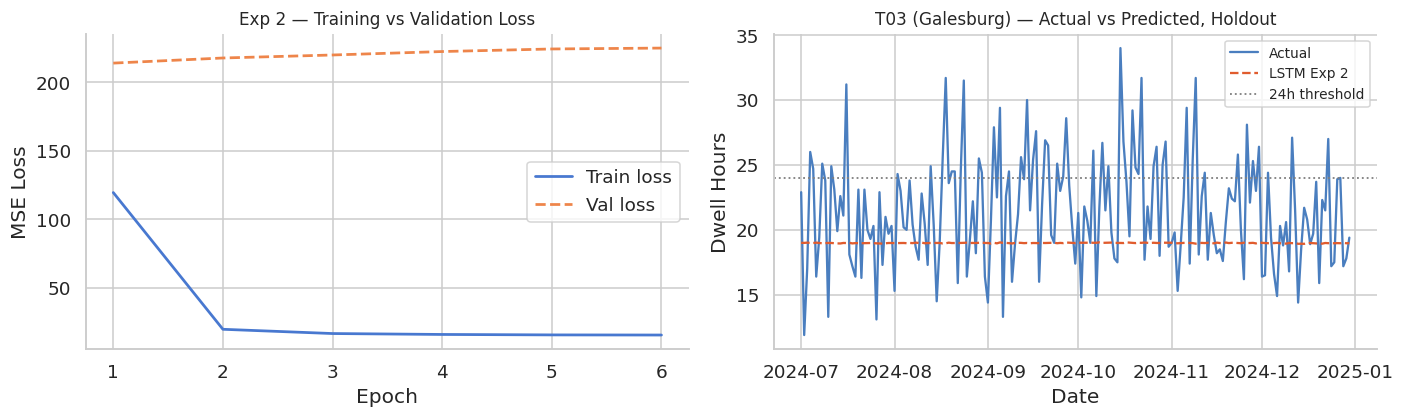

In [11]:
# Prediction range check
print("Prediction range — Experiment 2 vs actual test values")
print(f"  Predicted:  min={y_pred_lstm_exp2.min():.2f}h  max={y_pred_lstm_exp2.max():.2f}h  mean={y_pred_lstm_exp2.mean():.2f}h")
print(f"  Actual:     min={y_test.min():.2f}h  max={y_test.max():.2f}h  mean={y_test.mean():.2f}h")

epochs_ran = range(1, len(history_exp2.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: training vs validation loss
ax = axes[0]
ax.plot(epochs_ran, history_exp2.history["loss"], label="Train loss", linewidth=1.8)
ax.plot(epochs_ran, history_exp2.history["val_loss"], label="Val loss", linewidth=1.8, linestyle="--")
ax.set_title("Exp 2 — Training vs Validation Loss", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
sns.despine(ax=ax)

# Right: T03 actual vs predicted during holdout
test_terminals_arr = target_terminals[test_seq_mask]
t03_mask = test_terminals_arr == "T03"
t03_dates = test_dates[t03_mask]
t03_actual = y_test[t03_mask]
t03_pred = y_pred_lstm_exp2[t03_mask]

ax = axes[1]
ax.plot(t03_dates, t03_actual, label="Actual", linewidth=1.5, color="#4a7ebf")
ax.plot(t03_dates, t03_pred, label="LSTM Exp 2", linewidth=1.5, linestyle="--", color="#e05c2e")
ax.axhline(24, color="gray", linestyle=":", linewidth=1.2, label="24h threshold")
ax.set_title("T03 (Galesburg) — Actual vs Predicted, Holdout", fontsize=11)
ax.set_xlabel("Date")
ax.set_ylabel("Dwell Hours")
ax.legend(fontsize=9)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## Conclusion from Temporal Experiment 2

Temporal Experiment 2 used a more disciplined time-based validation design by separating the training-period sequences into an earlier subtraining set and a later validation set. This produced a small improvement over the first LSTM benchmark, reducing test RMSE from `7.576` to `7.500` and test MAE from `5.228` to `5.167`.

However, the second LSTM experiment still underperformed all Phase 1 benchmarks, including naive persistence, the baseline LightGBM model, and the tuned LightGBM model. This indicates that the validation design alone was not the main reason for the weak temporal-model results. In its current form, the 7-day single-layer LSTM does not provide a competitive forecasting alternative for next-day terminal dwell.

At this stage, the tuned LightGBM model remains the strongest benchmark for the Rail Operations Forecaster project. The temporal modeling work is still valuable because it demonstrates that a reasonable deep-learning extension was tested carefully, compared fairly, and reported honestly. The evidence so far suggests that the predictive structure in this dataset is captured more effectively by the tuned tabular model than by the initial LSTM sequence architecture.

## Phase 2 takeaway

Phase 2 tested whether short-run temporal modeling could improve next-day dwell forecasting beyond the Phase 1 tabular models. Two LSTM experiments were evaluated using the same holdout test period that began on `2024-07-01`.

The first experiment used a basic single-layer 7-day LSTM with Keras's built-in validation split — a design that, as described above, produced a structurally biased validation slice for this multi-terminal dataset. The second experiment corrected the validation design by using an explicit time-based split within the training period. Although the second approach slightly improved the LSTM's holdout metrics, both temporal experiments remained substantially worse than the tuned LightGBM, and both also underperformed the naive persistence baseline.

**The Phase 2 gate was not cleared.**

The project roadmap defined the Phase 2 gate as follows: *"The temporal model must demonstrably outperform LightGBM on multi-step forecasts or regime-change detection. If it doesn't, that finding is documented as a legitimate result — not a failure."*

Neither LSTM experiment met this bar. The tuned LightGBM holdout RMSE of `3.749` was not matched or exceeded by either temporal model. This is documented here as a legitimate negative result: the initial 7-day single-layer LSTM architecture does not add forecasting value over the Phase 1 tabular approach for this dataset, and the Phase 1 tuned LightGBM model remains the project's strongest forecasting benchmark.

Future temporal experiments — if pursued — should address both the architectural scope of the LSTM design and the question of whether the 7-day input window is well-matched to the sequential patterns present in the data. Whether to replace terminal dummy variables with an embedding layer — or remove terminal identity entirely — is also worth evaluating, given that the Phase 1 ablation showed operational features carry most of the predictive signal without `terminal_id`.